## P2.d — Entidades, grupos y rate de fraccionamiento

- **Entrada:** `data/p2/pares/` + `data/final/` (total de procesos por entidad)
- **Salida:** `data/p2/entidades/` — agregado por entidad con el rate
- Se analizan los pares, se encadenan en grupos y se calcula de cada cuántas contrataciones aparece un posible fraccionamiento

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes y funciones compartidas (`02_P2/p2_funciones.ipynb`)

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
ruta_funciones = str(proyecto / "02_P2" / "p2_funciones.ipynb")
%run $ruta_funciones

final_dir     = proyecto / "data" / "final"
firmas_dir    = proyecto / "data" / "p2" / "firmas"
pares_dir     = proyecto / "data" / "p2" / "pares"
entidades_dir = proyecto / "data" / "p2" / "entidades"

/opt/conda/lib/python3.11/site-packages/nbformat/__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("p2_d_entidades_rate")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 3.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga

In [5]:
assert pares_dir.exists(), f"No se encuentra {pares_dir}; corre c_lsh_pares.ipynb"
procesos = spark.read.parquet(str(final_dir)).select("ocid", "entidad", "region", "fecha", "monto_final", "descripcion")
pares    = spark.read.parquet(str(pares_dir)).cache()
N, n_pares = procesos.count(), pares.count()

n_sosp = pares.select(F.explode(F.array("ocid_1", "ocid_2")).alias("ocid")).distinct().count()
print(f"Pares: {n_pares:,} | procesos involucrados: {n_sosp:,} ({n_sosp / N:.2%} de {N:,}) | entidades: {pares.select('entidad').distinct().count():,}")

Pares: 141,935 | procesos involucrados: 36,740 (15.89% de 231,171) | entidades: 2,336


### 2. Qué tipo de pares son

- `texto_identico` + `mismo_dia`: casi-duplicados exactos vistos en el EDA (posibles republicaciones). El resto es lo que aporta la similitud aproximada
- `tramo_suma > tramo_1`: la compra sumada saltaría de tramo — la lógica del fraccionamiento

In [6]:
pares.groupBy("texto_identico", "mismo_dia").count().orderBy(F.desc("count")).show()
print("Pares cuya suma salta a un tramo superior:", f"{pares.where(F.col('tramo_suma') > F.greatest('tramo_1', 'tramo_2')).count():,} de {n_pares:,}")
pares.groupBy("tramo_1", "tramo_suma").count().orderBy(F.desc("count")).show(8)

+--------------+---------+-----+
|texto_identico|mismo_dia|count|
+--------------+---------+-----+
|          true|    false|90241|
|          true|     true|45597|
|         false|     true| 3447|
|         false|    false| 2650|
+--------------+---------+-----+

Pares cuya suma salta a un tramo superior: 32,725 de 141,935
+-----------+-----------+-----+
|    tramo_1| tramo_suma|count|
+-----------+-----------+-----+
|     1_<50k|     1_<50k|80483|
|     1_<50k| 2_50k-200k|30411|
| 2_50k-200k| 2_50k-200k| 8898|
|0_sin_monto|0_sin_monto| 4437|
|  3_200k-1M|  3_200k-1M| 4109|
| 2_50k-200k|  3_200k-1M| 3059|
|    4_1M-5M|    4_1M-5M| 2692|
|      5_>5M|      5_>5M| 2518|
+-----------+-----------+-----+
only showing top 8 rows



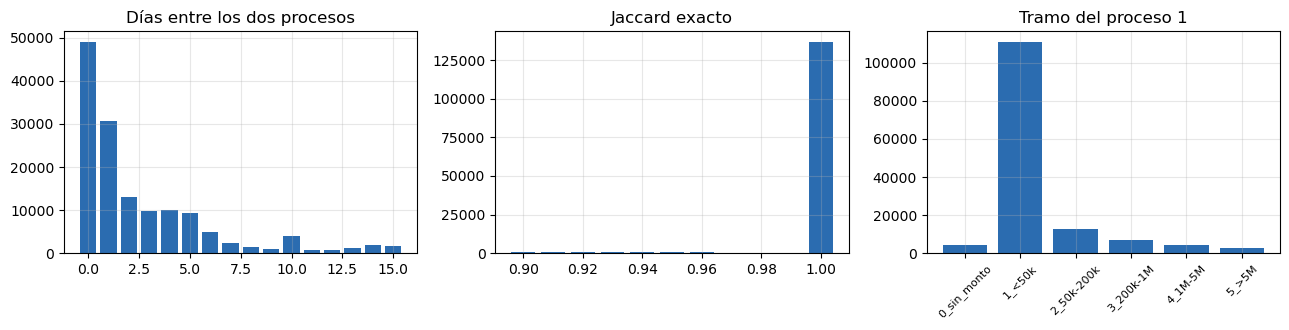

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
d = pares.groupBy("dias_diferencia").count().orderBy("dias_diferencia").toPandas()
ax[0].bar(d["dias_diferencia"], d["count"], color="#2b6cb0"); ax[0].set_title("Días entre los dos procesos")
j = pares.groupBy(F.round("jaccard", 2).alias("j")).count().orderBy("j").toPandas()
ax[1].bar(j["j"], j["count"], width=.008, color="#2b6cb0"); ax[1].set_title("Jaccard exacto")
t = pares.groupBy("tramo_1").count().orderBy("tramo_1").toPandas()
ax[2].bar(t["tramo_1"], t["count"], color="#2b6cb0"); ax[2].set_title("Tramo del proceso 1"); ax[2].tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

### 3. Grupos (componentes conexas)

- Si A~B y B~C, los tres son un grupo. Propagación de etiquetas en Spark: cada proceso toma el menor `ocid` de sus vecinos hasta converger

In [8]:
aristas = pares.select("ocid_1", "ocid_2").union(pares.select(F.col("ocid_2").alias("ocid_1"), F.col("ocid_1").alias("ocid_2")))
etiquetas = aristas.select(F.col("ocid_1").alias("ocid")).distinct().withColumn("grupo", F.col("ocid"))

for it in range(20):
    vecinos = aristas.join(etiquetas, aristas.ocid_2 == etiquetas.ocid).groupBy("ocid_1").agg(F.min("grupo").alias("g_vec"))
    nuevas = etiquetas.join(vecinos, etiquetas.ocid == vecinos.ocid_1, "left").select("ocid", F.least("grupo", "g_vec").alias("grupo")).cache()
    cambios = etiquetas.join(nuevas, "ocid").where(etiquetas.grupo != nuevas.grupo).count()
    etiquetas = nuevas
    if cambios == 0:
        break
grupos = etiquetas.groupBy("grupo").agg(F.count("*").alias("procesos_en_grupo"))
print(f"Convergió en {it + 1} iteraciones | grupos: {grupos.count():,}")
grupos.groupBy("procesos_en_grupo").count().orderBy("procesos_en_grupo").show()

Convergió en 5 iteraciones | grupos: 15,796
+-----------------+-----+
|procesos_en_grupo|count|
+-----------------+-----+
|                2|13676|
|                3| 1568|
|                4|  301|
|                5|   90|
|                6|   42|
|                7|   32|
|                8|    7|
|                9|    6|
|               10|    4|
|               11|   12|
|               12|    4|
|               13|    7|
|               14|    1|
|               15|    3|
|               16|    4|
|               17|    3|
|               18|    2|
|               19|    2|
|               20|    2|
|               21|    2|
+-----------------+-----+
only showing top 20 rows



In [9]:
info = etiquetas.join(procesos, "ocid").join(grupos, "grupo")
for g in info.where("procesos_en_grupo >= 3").select("grupo", "entidad", "procesos_en_grupo").distinct().orderBy(F.desc("procesos_en_grupo")).limit(3).collect():
    print(f"\n=== {g['entidad']} — {g['procesos_en_grupo']} procesos")
    (info.where(F.col("grupo") == g["grupo"]).orderBy("fecha")
         .select(F.date_format("fecha", "yyyy-MM-dd").alias("fecha"), F.round("monto_final").alias("monto"), F.substring("descripcion", 1, 90).alias("descripcion"))
         .show(8, truncate=False))


=== ORGANISMO DE EVALUACION Y FISCALIZACION AMBIENTAL — 481 procesos
+----------+-------+---------------------------------+
|fecha     |monto  |descripcion                      |
+----------+-------+---------------------------------+
|2025-02-14|8000.0 |SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|24000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|8000.0 |SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|18000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|24000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|4000.0 |SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|3000.0 |SERVICIO DE SUPERVISIÓN AMBIENTAL|
|2025-02-14|30000.0|SERVICIO DE SUPERVISIÓN AMBIENTAL|
+----------+-------+---------------------------------+
only showing top 8 rows


=== ORGANISMO DE EVALUACION Y FISCALIZACION AMBIENTAL — 160 procesos
+----------+-------+-------------------------------------------+
|fecha     |monto  |descripcion                                |
+----------+-------+-------------------------

### 4. Rate de fraccionamiento

- **Numerador:** procesos distintos de la entidad en algún par ≥ 0.90 (se cuentan procesos, no pares: un grupo de 4 genera 6 pares)
- **Denominador:** total de procesos de la entidad 2023-2025
- `rate = sospechosos / total`; `uno_de_cada = total / sospechosos`
- `rate_estricto`: excluye pares con texto idéntico y mismo día (posibles republicaciones)

In [10]:
total_ent = procesos.groupBy("entidad").agg(F.count("*").alias("procesos_total"), F.first("region").alias("region"))
sosp = pares.select("entidad", F.explode(F.array("ocid_1", "ocid_2")).alias("ocid")).distinct().groupBy("entidad").agg(F.count("*").alias("procesos_sospechosos"))
sosp_e = (pares.where(~(F.col("texto_identico") & F.col("mismo_dia"))).select("entidad", F.explode(F.array("ocid_1", "ocid_2")).alias("ocid")).distinct()
               .groupBy("entidad").agg(F.count("*").alias("procesos_sospechosos_estricto")))
par_e = pares.groupBy("entidad").agg(F.count("*").alias("pares"), F.sum("monto_suma").alias("monto_involucrado"), F.round(F.avg("dias_diferencia"), 1).alias("dias_promedio"))
gru_e = etiquetas.join(procesos.select("ocid", "entidad"), "ocid").select("entidad", "grupo").distinct().groupBy("entidad").agg(F.count("*").alias("grupos"))

entidades = (total_ent.join(sosp, "entidad", "left").join(sosp_e, "entidad", "left").join(par_e, "entidad", "left").join(gru_e, "entidad", "left")
                      .fillna(0, ["procesos_sospechosos", "procesos_sospechosos_estricto", "pares", "grupos", "monto_involucrado"])
                      .withColumn("rate", F.round(F.col("procesos_sospechosos") / F.col("procesos_total"), 4))
                      .withColumn("rate_estricto", F.round(F.col("procesos_sospechosos_estricto") / F.col("procesos_total"), 4))
                      .withColumn("uno_de_cada", F.when(F.col("procesos_sospechosos") > 0, F.round(F.col("procesos_total") / F.col("procesos_sospechosos"), 1))))
entidades.write.mode("overwrite").parquet(str(entidades_dir))
entidades = spark.read.parquet(str(entidades_dir)).cache()

tot = entidades.agg(F.sum("procesos_total").alias("t"), F.sum("procesos_sospechosos").alias("s"), F.sum("procesos_sospechosos_estricto").alias("se")).first()
print(f"Rate global: {tot['s']:,} / {tot['t']:,} = {tot['s'] / tot['t']:.2%} → 1 de cada {tot['t'] / max(tot['s'], 1):.0f}")
print(f"Rate estricto: {tot['se'] / tot['t']:.2%} → 1 de cada {tot['t'] / max(tot['se'], 1):.0f}")
print(f"Entidades con pares: {entidades.where('pares > 0').count():,} de {entidades.count():,}")

Rate global: 36,740 / 231,171 = 15.89% → 1 de cada 6
Rate estricto: 6.73% → 1 de cada 15
Entidades con pares: 2,336 de 2,995


### 5. Ranking de entidades

- Sólo entidades con ≥ 50 procesos, para que una entidad chica no encabece la lista con 2 casos

In [11]:
MIN_PROC = 50
(entidades.where(f"procesos_total >= {MIN_PROC} AND pares > 0").orderBy(F.desc("rate"))
          .select("entidad", "region", "procesos_total", "procesos_sospechosos", "pares", "grupos", "rate", "rate_estricto", "uno_de_cada").show(15, truncate=45))
(entidades.orderBy(F.desc("pares"))
          .select("entidad", "procesos_total", "procesos_sospechosos", "pares", "grupos", F.round("monto_involucrado").alias("monto_involucrado"), "rate").show(10, truncate=45))

+---------------------------------------------+-------------------------+--------------+--------------------+------+------+------+-------------+-----------+
|                                      entidad|                   region|procesos_total|procesos_sospechosos| pares|grupos|  rate|rate_estricto|uno_de_cada|
+---------------------------------------------+-------------------------+--------------+--------------------+------+------+------+-------------+-----------+
|ORGANISMO DE EVALUACION Y FISCALIZACION AM...|                     LIMA|          3499|                3016|114841|   287| 0.862|       0.8245|        1.2|
|GOBIERNO REGIONAL DE UCAYALI - DIRECCIÓN R...|         CORONEL PORTILLO|           171|                 120|   331|    23|0.7018|       0.6784|        1.4|
|INSTITUTO VIAL PROVINCIAL DE PASCO - IVP-P...|                    PASCO|           163|                 110|    68|    53|0.6748|       0.3681|        1.5|
|INSTITUTO VIAL PROVINCIAL MUNICIPAL DE PAC...|           

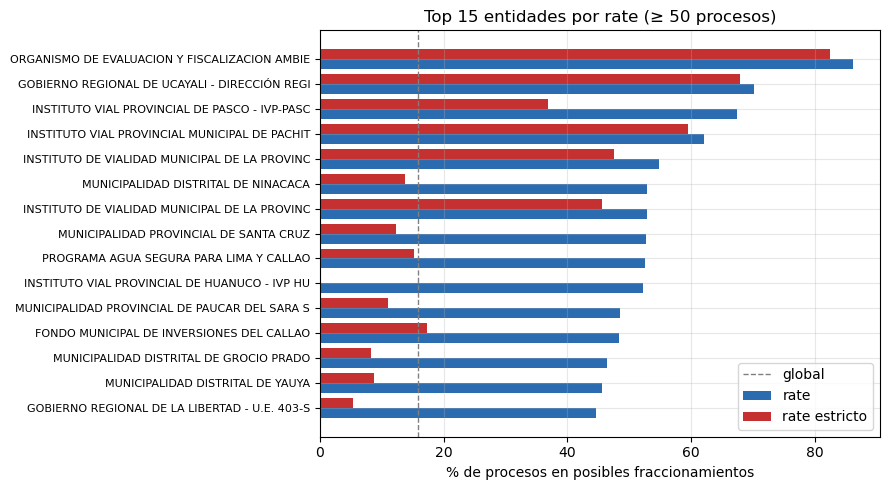

In [12]:
top = entidades.where(f"procesos_total >= {MIN_PROC} AND pares > 0").orderBy(F.desc("rate")).limit(15).select("entidad", "rate", "rate_estricto").toPandas().iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5)); y = np.arange(len(top))
ax.barh(y - .2, top["rate"] * 100, .4, label="rate", color="#2b6cb0"); ax.barh(y + .2, top["rate_estricto"] * 100, .4, label="rate estricto", color="#c53030")
ax.axvline(tot["s"] / tot["t"] * 100, color="gray", ls="--", lw=1, label="global")
ax.set_yticks(y); ax.set_yticklabels(top["entidad"].str[:45], fontsize=8); ax.set_xlabel("% de procesos en posibles fraccionamientos")
ax.set_title(f"Top 15 entidades por rate (≥ {MIN_PROC} procesos)"); ax.legend(); plt.tight_layout(); plt.show()

### 6. Salidas de P2

```python
firmas    = spark.read.parquet("data/p2/firmas")      # firma MinHash por proceso
pares     = spark.read.parquet("data/p2/pares")       # pares ≥ 0.90, misma entidad, ≤ 15 días
entidades = spark.read.parquet("data/p2/entidades")   # rate por entidad
```

In [13]:
for d_ in [firmas_dir, pares_dir, entidades_dir]:
    df_ = spark.read.parquet(str(d_))
    print(f"{str(d_.relative_to(proyecto)):22s} {df_.count():>9,} filas x {len(df_.columns):>2} columnas")

data/p2/firmas           231,171 filas x  6 columnas
data/p2/pares            141,935 filas x 29 columnas
data/p2/entidades          2,995 filas x 12 columnas


### 7. Cierre

In [14]:
spark.stop()